In [ ]:
#!pip install timm

In [174]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import io
import matplotlib.pyplot as plt
import timm

from PIL import Image
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
# Для воспроизводимости результатов
torch.manual_seed(42)
np.random.seed(42)

In [126]:
sample_submission = pd.read_csv("./data/sample_submission.csv")
df_train = pd.read_parquet("./data/train.parquet")
df_test = pd.read_parquet("./data/test.parquet")

In [127]:
# Гиперпараметры
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

# Выбор устройства для вычислений
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Используемое устройство: {device}")

Используемое устройство: mps



Пример данных из обучающего набора (df_train):


,image_1,image_2,is_image1_better
0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'RIFF\x06%\x01\x00WEBPVP8 \xfa$\x01\x00\xb0A\...,1
1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'RIFFL\x99\x01\x00WEBPVP8 @\x99\x01\x00p\xbb\...,0
2,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,"b'RIFF8@\x02\x00WEBPVP8 ,@\x02\x00\x106\t\x9d\...",1
3,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'RIFFv\n\x01\x00WEBPVP8 j\n\x01\x00p\xbe\x04\...,0
4,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,b'RIFF\xde|\x00\x00WEBPVP8 \xd2|\x00\x00PH\x03...,0



Пример первого изображения из первой строки:


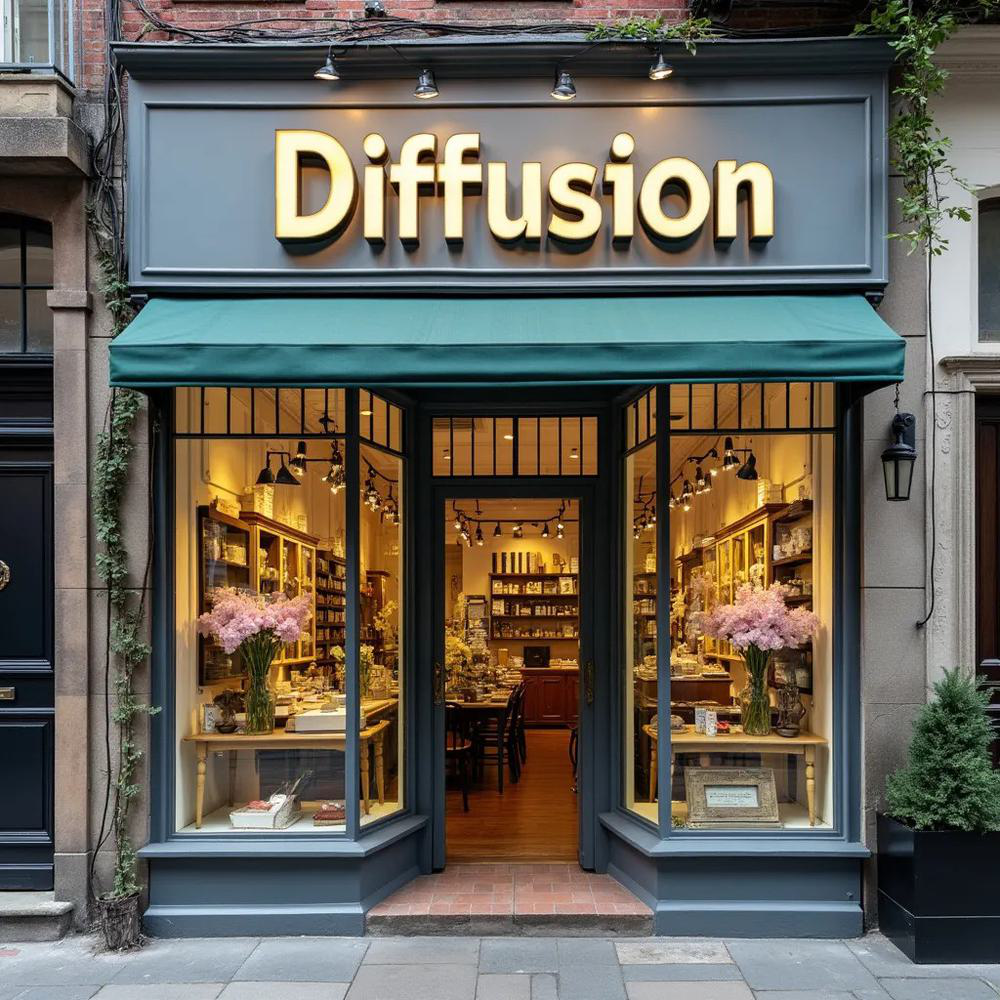

In [128]:
print("\nПример данных из обучающего набора (df_train):")
display(df_train.head())

# Посмотрим на одно из сгенерированных изображений
print("\nПример первого изображения из первой строки:")
display(Image.open(io.BytesIO(df_train.iloc[0]['image_1'])))

In [129]:
import io

class ImagePairDataset(Dataset):
    """
    Класс Dataset для загрузки и предобработки пар изображений.
    Работает как с обучающим, так и с тестовым набором данных.
    """
    def __init__(self, dataframe, transform=None, is_test=False):
        """
        :param dataframe: pandas.DataFrame, содержащий колонки 'image_1', 'image_2' и опционально 'is_image1_better'
        :param transform: torchvision трансформации, применяемые к изображениям
        :param is_test: если True, метки не ожидаются
        """
        self.dataframe = dataframe
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        try:
            image1 = Image.open(io.BytesIO(row['image_1'])).convert('RGB')
            image2 = Image.open(io.BytesIO(row['image_2'])).convert('RGB')
        except Exception as e:
            print(f"Ошибка загрузки изображения по индексу {idx}: {e}")
            raise

        if self.transform:
            image1 = self.transform(image1)
            image2 = self.transform(image2)

        if self.is_test:
            return image1, image2
        else:
            label = torch.tensor([float(row['is_image1_better'])], dtype=torch.float32)
            return image1, image2, label


In [130]:
model = timm.create_model('vit_small_patch16_224_dino', pretrained=True)

/Users/katiegalaeva/miniconda3/envs/catboost_env/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


In [131]:
print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [159]:

# === Siamese Модель ===
class SiameseComparator(nn.Module):
    def __init__(self, freeze_partial_encoder=True):
        super(SiameseComparator, self).__init__()

        self.encoder = timm.create_model('vit_small_patch16_224_dino', pretrained=True)
        self.encoder.head = nn.Identity()  

        if freeze_partial_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

        self.classifier_head = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),

            nn.Linear(128, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.5),

            nn.Linear(32, 1) 
        )

    def forward(self, img1, img2):
        features1 = self.encoder(img1)
        features2 = self.encoder(img2)

        score1 = self.classifier_head(features1).squeeze(1)
        score2 = self.classifier_head(features2).squeeze(1)

        return score1, score2


In [160]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images1, images2, labels in tqdm(dataloader, desc="Обучение"):
        images1, images2, labels = images1.to(device), images2.to(device),  labels.to(device).view(-1).float()

        optimizer.zero_grad()
        score1, score2 = model(images1, images2)

        targets = torch.where(labels == 1, torch.ones_like(labels), -torch.ones_like(labels))
        loss = criterion(score1, score2, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images1.size(0)
        correct_predictions += ((score1 > score2) == (labels == 1)).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc


def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for images1, images2, labels in tqdm(dataloader, desc="Оценка"):
            images1, images2, labels = images1.to(device), images2.to(device),  labels.to(device).view(-1).float()

            score1, score2 = model(images1, images2)
            targets = torch.where(labels == 1, torch.ones_like(labels), -torch.ones_like(labels))

            loss = criterion(score1, score2, targets)

            running_loss += loss.item() * images1.size(0)
            correct_predictions += ((score1 > score2) == (labels == 1)).sum().item()
            total_samples += labels.size(0)

            diff = (score1 - score2).detach().cpu()
            all_scores.append(diff)
            all_labels.append(labels.cpu())

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples

    all_scores = torch.cat(all_scores)
    all_labels = torch.cat(all_labels)
    all_probs = 1 / (1 + np.exp(-all_scores.numpy()))  # Sigmoid

    try:
        auc = roc_auc_score(all_labels.numpy(), all_probs)
    except:
        auc = None

    return epoch_loss, epoch_acc, auc


In [161]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train, test = train_test_split(df_train, test_size=0.2, random_state=42)
X_train, X_val = train_test_split(train, test_size=0.2, random_state=42)

train_dataset = ImagePairDataset(X_train, transform=train_transforms, is_test=False)
val_dataset = ImagePairDataset(X_val, transform=val_transforms, is_test=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = SiameseComparator(freeze_partial_encoder=True).to(device)

encoder_params = [p for n, p in model.named_parameters() if "encoder" in n and p.requires_grad]
head_params = [p for n, p in model.named_parameters() if "classifier_head" in n]

optimizer = torch.optim.Adam([
    {'params': encoder_params, 'lr': 1e-2},
    {'params': head_params, 'lr': 1e-2}
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.MarginRankingLoss(margin=0.5)


/Users/katiegalaeva/miniconda3/envs/catboost_env/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


In [162]:
NUM_EPOCHS = 30
PATIENCE = 3
best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_path = "best_model.pth"

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Эпоха {epoch + 1}/{NUM_EPOCHS} ---")

    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, auc = evaluate_model(model, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | AUC: {auc:.4f}" if auc else "AUC: N/A")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Сохранена новая лучшая модель (Val Loss: {val_loss:.4f})")
    else:
        epochs_without_improvement += 1
        print(f" Улучшения нет {epochs_without_improvement}/{PATIENCE} эпох")
    
    print(f"Current Learning Rates: {scheduler.get_last_lr()}")

    scheduler.step()

    if epochs_without_improvement >= PATIENCE:
        print(f"\nОстановка обучения: нет улучшения {PATIENCE} эпох подряд")
        break



--- Эпоха 1/30 ---


Оценка: 100%|██████████| 88/88 [00:52<00:00,  1.67it/s]


Train Loss: 0.5109 | Train Acc: 0.5152
Val   Loss: 0.5040 | Val   Acc: 0.4835 | AUC: 0.5001
Сохранена новая лучшая модель (Val Loss: 0.5040)
Current Learning Rates: [0.01, 0.01]

--- Эпоха 2/30 ---


Оценка: 100%|██████████| 88/88 [00:57<00:00,  1.54it/s]


Train Loss: 0.5026 | Train Acc: 0.5039
Val   Loss: 0.5264 | Val   Acc: 0.5043 | AUC: 0.5587
 Улучшения нет 1/3 эпох
Current Learning Rates: [0.009755282581475769, 0.009755282581475769]

--- Эпоха 3/30 ---


...

Train Loss: 0.4343 | Train Acc: 0.5996
Val   Loss: 0.4926 | Val   Acc: 0.5344 | AUC: 0.6225
 Улучшения нет 1/3 эпох
Current Learning Rates: [0.003454915028125263, 0.003454915028125263]

--- Эпоха 8/30 ---


Оценка: 100%|██████████| 88/88 [01:07<00:00,  1.30it/s]


Train Loss: 0.4305 | Train Acc: 0.6057
Val   Loss: 0.4856 | Val   Acc: 0.5416 | AUC: 0.6263
 Улучшения нет 2/3 эпох
Current Learning Rates: [0.0020610737385376348, 0.0020610737385376348]

--- Эпоха 9/30 ---


Оценка: 100%|██████████| 88/88 [01:07<00:00,  1.30it/s]

Train Loss: 0.4300 | Train Acc: 0.6028
Val   Loss: 0.4839 | Val   Acc: 0.5387 | AUC: 0.6293
 Улучшения нет 3/3 эпох
Current Learning Rates: [0.0009549150281252633, 0.0009549150281252633]

Остановка обучения: нет улучшения 3 эпох подряд


In [164]:
test_dataset = ImagePairDataset(test, transform=val_transforms, is_test=False)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [165]:
print("\nФинальная оценка на тестовом наборе")
test_loss, test_acc, roc = evaluate_model(model, test_loader, criterion, device)

print(f"\nИтог на тестовых данных:")
print(f"Потери: {test_loss:.4f} | Точность: {test_acc:.4f}")


Финальная оценка на тестовом наборе


Оценка: 100%|██████████| 109/109 [01:26<00:00,  1.26it/s]


Итог на тестовых данных:
Потери: 0.4834 | Точность: 0.5264


ROC-AUC на тестовых данных: 0.6132


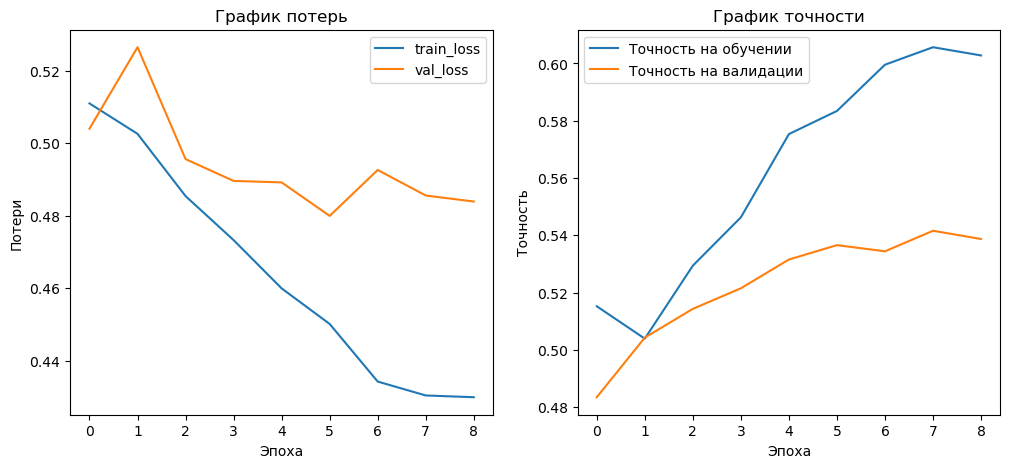

In [175]:

# выводим ROC-AUC

print(f"ROC-AUC на тестовых данных: {roc:.4f}")

# Также можно визуализировать график обучения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.title('График потерь')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Точность на обучении')
plt.plot(history['val_acc'], label='Точность на валидации')
plt.title('График точности')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.show()

In [167]:
import os
from datetime import datetime
import joblib 


timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_dir = os.path.join("runs", timestamp)
os.makedirs(output_dir, exist_ok=True)

model_path = os.path.join(output_dir, f"model{timestamp}.pth")
submission_path = os.path.join(output_dir, f"submission{timestamp}.csv")
submission_path_prob = os.path.join(output_dir, f"submission{timestamp}prob.csv")

In [ ]:

torch.save(model.state_dict(), model_path)
print(f"Модель сохранена в файл: {model_path}")


loaded_model = SiameseComparator()

loaded_model.load_state_dict(torch.load(model_path))

loaded_model.to(device)
loaded_model.eval()

print("\nМодель успешно загружена и готова к использованию")

In [169]:
test_dataset = ImagePairDataset(df_test, transform=val_transforms, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [170]:

all_preds = []

with torch.no_grad(): 
    for images1, images2 in tqdm(test_loader, desc="Оценка"):
        images1, images2 = images1.to(device), images2.to(device)

        outputs = loaded_model(images1, images2)  
        logits = outputs[0] 
        probs = torch.sigmoid(logits)     
        preds = (probs > 0.5).int().squeeze().cpu().tolist() 

        all_preds.extend(preds)


Оценка: 100%|██████████| 269/269 [03:32<00:00,  1.26it/s]


In [171]:

submission_df = pd.DataFrame({
    'index': list(range(len(all_preds))),
    'is_image1_better': all_preds
})

submission_df.to_csv(submission_path, index=False)


In [172]:
all_preds = []

with torch.no_grad(): 
    for images1, images2 in tqdm(test_loader, desc="Оценка"):
        images1, images2 = images1.to(device), images2.to(device)

        outputs = loaded_model(images1, images2)  
        logits = outputs[0] 
        probs = torch.sigmoid(logits)   

        all_preds.extend(probs.cpu().tolist())


Оценка: 100%|██████████| 269/269 [03:22<00:00,  1.33it/s]


In [173]:

submission_df = pd.DataFrame({
    'index': list(range(len(all_preds))),
    'is_image1_better': all_preds
})

submission_df.to_csv(submission_path_prob, index=False)